In [50]:
import os
import re

import matplotlib.pyplot as plt

In [51]:
log = """
[2025-07-07 16:23:10,151][pytorch_lightning.accelerators.cuda][INFO] - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,]
[2025-07-07 16:28:12,530][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 8, global step 1000: 'val/loss' was not in top 1
[2025-07-07 16:28:26,076][byprot.tasks][INFO] - Validation Info @ (Epoch 8, global step 1000): val/loss=0.583, val/nll_loss=0.583, val/ppl=1.792, val/ppl_best=1.792
[2025-07-07 16:33:41,885][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 17, global step 2000: 'val/loss' reached 0.58328 (best 0.58328), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_1999.0-loss_0.58.ckpt' as top 1
[2025-07-07 16:34:00,606][byprot.tasks][INFO] - Validation Info @ (Epoch 17, global step 2000): val/loss=0.506, val/nll_loss=0.506, val/ppl=1.659, val/ppl_best=1.659
[2025-07-07 16:39:26,004][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 25, global step 3000: 'val/loss' reached 0.50624 (best 0.50624), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_2999.0-loss_0.51.ckpt' as top 1
[2025-07-07 16:39:45,571][byprot.tasks][INFO] - Validation Info @ (Epoch 25, global step 3000): val/loss=0.414, val/nll_loss=0.414, val/ppl=1.512, val/ppl_best=1.512
[2025-07-07 16:45:13,780][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 34, global step 4000: 'val/loss' reached 0.41360 (best 0.41360), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_3999.0-loss_0.41.ckpt' as top 1
[2025-07-07 16:45:31,349][byprot.tasks][INFO] - Validation Info @ (Epoch 34, global step 4000): val/loss=0.383, val/nll_loss=0.383, val/ppl=1.467, val/ppl_best=1.467
[2025-07-07 16:50:26,375][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 43, global step 5000: 'val/loss' reached 0.38303 (best 0.38303), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_4999.0-loss_0.38.ckpt' as top 1
[2025-07-07 16:50:42,574][byprot.tasks][INFO] - Validation Info @ (Epoch 43, global step 5000): val/loss=0.358, val/nll_loss=0.358, val/ppl=1.431, val/ppl_best=1.431
[2025-07-07 16:55:21,781][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 51, global step 6000: 'val/loss' reached 0.35822 (best 0.35822), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_5999.0-loss_0.36.ckpt' as top 1
[2025-07-07 16:55:37,042][byprot.tasks][INFO] - Validation Info @ (Epoch 51, global step 6000): val/loss=0.301, val/nll_loss=0.301, val/ppl=1.351, val/ppl_best=1.351
[2025-07-07 17:00:24,560][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 60, global step 7000: 'val/loss' reached 0.30090 (best 0.30090), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_6999.0-loss_0.30.ckpt' as top 1
[2025-07-07 17:00:40,382][byprot.tasks][INFO] - Validation Info @ (Epoch 60, global step 7000): val/loss=0.282, val/nll_loss=0.282, val/ppl=1.326, val/ppl_best=1.326
[2025-07-07 17:05:17,331][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 68, global step 8000: 'val/loss' reached 0.28222 (best 0.28222), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_7999.0-loss_0.28.ckpt' as top 1
[2025-07-07 17:05:33,059][byprot.tasks][INFO] - Validation Info @ (Epoch 68, global step 8000): val/loss=0.237, val/nll_loss=0.237, val/ppl=1.268, val/ppl_best=1.268
[2025-07-07 17:10:29,012][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 77, global step 9000: 'val/loss' reached 0.23738 (best 0.23738), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_8999.0-loss_0.24.ckpt' as top 1
[2025-07-07 17:10:44,062][byprot.tasks][INFO] - Validation Info @ (Epoch 77, global step 9000): val/loss=0.204, val/nll_loss=0.204, val/ppl=1.227, val/ppl_best=1.227
[2025-07-07 17:15:37,957][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 86, global step 10000: 'val/loss' reached 0.20424 (best 0.20424), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_9999.0-loss_0.20.ckpt' as top 1
[2025-07-07 17:15:53,700][byprot.tasks][INFO] - Validation Info @ (Epoch 86, global step 10000): val/loss=0.190, val/nll_loss=0.190, val/ppl=1.209, val/ppl_best=1.209
[2025-07-07 17:20:31,384][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 94, global step 11000: 'val/loss' reached 0.19010 (best 0.19010), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_10999.0-loss_0.19.ckpt' as top 1
[2025-07-07 17:20:47,421][byprot.tasks][INFO] - Validation Info @ (Epoch 94, global step 11000): val/loss=0.164, val/nll_loss=0.164, val/ppl=1.178, val/ppl_best=1.178
[2025-07-07 17:25:39,836][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 103, global step 12000: 'val/loss' reached 0.16365 (best 0.16365), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_11999.0-loss_0.16.ckpt' as top 1
[2025-07-07 17:25:56,128][byprot.tasks][INFO] - Validation Info @ (Epoch 103, global step 12000): val/loss=0.149, val/nll_loss=0.149, val/ppl=1.161, val/ppl_best=1.161
[2025-07-07 17:30:45,349][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 112, global step 13000: 'val/loss' reached 0.14887 (best 0.14887), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_12999.0-loss_0.15.ckpt' as top 1
[2025-07-07 17:31:00,130][byprot.tasks][INFO] - Validation Info @ (Epoch 112, global step 13000): val/loss=0.136, val/nll_loss=0.136, val/ppl=1.145, val/ppl_best=1.145
[2025-07-07 17:35:49,434][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 120, global step 14000: 'val/loss' reached 0.13565 (best 0.13565), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_13999.0-loss_0.14.ckpt' as top 1
[2025-07-07 17:36:05,452][byprot.tasks][INFO] - Validation Info @ (Epoch 120, global step 14000): val/loss=0.109, val/nll_loss=0.109, val/ppl=1.116, val/ppl_best=1.116
[2025-07-07 17:41:03,895][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 129, global step 15000: 'val/loss' reached 0.10944 (best 0.10944), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_14999.0-loss_0.11.ckpt' as top 1
[2025-07-07 17:41:20,500][byprot.tasks][INFO] - Validation Info @ (Epoch 129, global step 15000): val/loss=0.097, val/nll_loss=0.097, val/ppl=1.102, val/ppl_best=1.102
[2025-07-07 17:46:04,155][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 137, global step 16000: 'val/loss' reached 0.09718 (best 0.09718), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_15999.0-loss_0.10.ckpt' as top 1
[2025-07-07 17:46:20,602][byprot.tasks][INFO] - Validation Info @ (Epoch 137, global step 16000): val/loss=0.087, val/nll_loss=0.087, val/ppl=1.091, val/ppl_best=1.091
[2025-07-07 17:51:20,797][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 146, global step 17000: 'val/loss' reached 0.08680 (best 0.08680), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_16999.0-loss_0.09.ckpt' as top 1
[2025-07-07 17:51:37,386][byprot.tasks][INFO] - Validation Info @ (Epoch 146, global step 17000): val/loss=0.078, val/nll_loss=0.078, val/ppl=1.081, val/ppl_best=1.081
[2025-07-07 17:56:39,426][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 155, global step 18000: 'val/loss' reached 0.07771 (best 0.07771), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_17999.0-loss_0.08.ckpt' as top 1
[2025-07-07 17:56:55,307][byprot.tasks][INFO] - Validation Info @ (Epoch 155, global step 18000): val/loss=0.070, val/nll_loss=0.070, val/ppl=1.073, val/ppl_best=1.073
[2025-07-07 18:01:47,243][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 163, global step 19000: 'val/loss' reached 0.07045 (best 0.07045), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_18999.0-loss_0.07.ckpt' as top 1
[2025-07-07 18:02:02,670][byprot.tasks][INFO] - Validation Info @ (Epoch 163, global step 19000): val/loss=0.064, val/nll_loss=0.064, val/ppl=1.066, val/ppl_best=1.066
[2025-07-07 18:06:58,596][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 172, global step 20000: 'val/loss' reached 0.06394 (best 0.06394), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_19999.0-loss_0.06.ckpt' as top 1
[2025-07-07 18:07:15,234][byprot.tasks][INFO] - Validation Info @ (Epoch 172, global step 20000): val/loss=0.055, val/nll_loss=0.055, val/ppl=1.056, val/ppl_best=1.056
[2025-07-07 18:12:13,549][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 181, global step 21000: 'val/loss' reached 0.05453 (best 0.05453), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_20999.0-loss_0.05.ckpt' as top 1
[2025-07-07 18:12:28,997][byprot.tasks][INFO] - Validation Info @ (Epoch 181, global step 21000): val/loss=0.056, val/nll_loss=0.056, val/ppl=1.058, val/ppl_best=1.056
[2025-07-07 18:17:14,052][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 189, global step 22000: 'val/loss' was not in top 1
[2025-07-07 18:17:27,413][byprot.tasks][INFO] - Validation Info @ (Epoch 189, global step 22000): val/loss=0.053, val/nll_loss=0.053, val/ppl=1.054, val/ppl_best=1.054
[2025-07-07 18:22:17,181][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 198, global step 23000: 'val/loss' reached 0.05286 (best 0.05286), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_22999.0-loss_0.05.ckpt' as top 1
[2025-07-07 18:22:32,861][byprot.tasks][INFO] - Validation Info @ (Epoch 198, global step 23000): val/loss=0.046, val/nll_loss=0.046, val/ppl=1.047, val/ppl_best=1.047
[2025-07-07 18:27:30,117][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 206, global step 24000: 'val/loss' reached 0.04578 (best 0.04578), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_23999.0-loss_0.05.ckpt' as top 1
[2025-07-07 18:27:45,529][byprot.tasks][INFO] - Validation Info @ (Epoch 206, global step 24000): val/loss=0.046, val/nll_loss=0.046, val/ppl=1.047, val/ppl_best=1.047
[2025-07-07 18:32:40,124][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 215, global step 25000: 'val/loss' was not in top 1
[2025-07-07 18:32:53,280][byprot.tasks][INFO] - Validation Info @ (Epoch 215, global step 25000): val/loss=0.038, val/nll_loss=0.038, val/ppl=1.039, val/ppl_best=1.039
[2025-07-07 18:37:41,511][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 224, global step 26000: 'val/loss' reached 0.03844 (best 0.03844), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_25999.0-loss_0.04.ckpt' as top 1
[2025-07-07 18:37:56,006][byprot.tasks][INFO] - Validation Info @ (Epoch 224, global step 26000): val/loss=0.040, val/nll_loss=0.040, val/ppl=1.041, val/ppl_best=1.039
[2025-07-07 18:42:40,447][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 232, global step 27000: 'val/loss' was not in top 1
[2025-07-07 18:42:53,320][byprot.tasks][INFO] - Validation Info @ (Epoch 232, global step 27000): val/loss=0.037, val/nll_loss=0.037, val/ppl=1.038, val/ppl_best=1.038
[2025-07-07 18:47:49,514][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 241, global step 28000: 'val/loss' reached 0.03736 (best 0.03736), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_27999.0-loss_0.04.ckpt' as top 1
[2025-07-07 18:48:04,027][byprot.tasks][INFO] - Validation Info @ (Epoch 241, global step 28000): val/loss=0.033, val/nll_loss=0.033, val/ppl=1.034, val/ppl_best=1.034
[2025-07-07 18:52:52,439][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 249, global step 29000: 'val/loss' reached 0.03328 (best 0.03328), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_28999.0-loss_0.03.ckpt' as top 1
[2025-07-07 18:53:07,997][byprot.tasks][INFO] - Validation Info @ (Epoch 249, global step 29000): val/loss=0.035, val/nll_loss=0.035, val/ppl=1.036, val/ppl_best=1.034
[2025-07-07 18:57:57,194][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 258, global step 30000: 'val/loss' was not in top 1
[2025-07-07 18:58:08,773][byprot.tasks][INFO] - Validation Info @ (Epoch 258, global step 30000): val/loss=0.030, val/nll_loss=0.030, val/ppl=1.030, val/ppl_best=1.030
[2025-07-07 19:02:59,441][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 267, global step 31000: 'val/loss' reached 0.02979 (best 0.02979), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_30999.0-loss_0.03.ckpt' as top 1
[2025-07-07 19:03:14,751][byprot.tasks][INFO] - Validation Info @ (Epoch 267, global step 31000): val/loss=0.029, val/nll_loss=0.029, val/ppl=1.030, val/ppl_best=1.030
[2025-07-07 19:07:57,959][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 275, global step 32000: 'val/loss' reached 0.02931 (best 0.02931), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_31999.0-loss_0.03.ckpt' as top 1
[2025-07-07 19:08:14,584][byprot.tasks][INFO] - Validation Info @ (Epoch 275, global step 32000): val/loss=0.030, val/nll_loss=0.030, val/ppl=1.031, val/ppl_best=1.030
[2025-07-07 19:13:14,798][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 284, global step 33000: 'val/loss' was not in top 1
[2025-07-07 19:13:27,406][byprot.tasks][INFO] - Validation Info @ (Epoch 284, global step 33000): val/loss=0.028, val/nll_loss=0.028, val/ppl=1.028, val/ppl_best=1.028
[2025-07-07 19:18:15,609][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 293, global step 34000: 'val/loss' reached 0.02784 (best 0.02784), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_33999.0-loss_0.03.ckpt' as top 1
[2025-07-07 19:18:32,428][byprot.tasks][INFO] - Validation Info @ (Epoch 293, global step 34000): val/loss=0.029, val/nll_loss=0.029, val/ppl=1.030, val/ppl_best=1.028
[2025-07-07 19:23:13,181][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 301, global step 35000: 'val/loss' was not in top 1
[2025-07-07 19:23:25,308][byprot.tasks][INFO] - Validation Info @ (Epoch 301, global step 35000): val/loss=0.029, val/nll_loss=0.029, val/ppl=1.030, val/ppl_best=1.028
[2025-07-07 19:28:14,658][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 310, global step 36000: 'val/loss' was not in top 1
[2025-07-07 19:28:26,846][byprot.tasks][INFO] - Validation Info @ (Epoch 310, global step 36000): val/loss=0.024, val/nll_loss=0.024, val/ppl=1.024, val/ppl_best=1.024
[2025-07-07 19:33:02,199][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 318, global step 37000: 'val/loss' reached 0.02354 (best 0.02354), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_36999.0-loss_0.02.ckpt' as top 1
[2025-07-07 19:33:16,832][byprot.tasks][INFO] - Validation Info @ (Epoch 318, global step 37000): val/loss=0.030, val/nll_loss=0.030, val/ppl=1.030, val/ppl_best=1.024
[2025-07-07 19:38:13,393][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 327, global step 38000: 'val/loss' was not in top 1
[2025-07-07 19:38:25,810][byprot.tasks][INFO] - Validation Info @ (Epoch 327, global step 38000): val/loss=0.023, val/nll_loss=0.023, val/ppl=1.023, val/ppl_best=1.023
[2025-07-07 19:43:23,632][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 336, global step 39000: 'val/loss' reached 0.02276 (best 0.02276), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_38999.0-loss_0.02.ckpt' as top 1
[2025-07-07 19:43:40,838][byprot.tasks][INFO] - Validation Info @ (Epoch 336, global step 39000): val/loss=0.020, val/nll_loss=0.020, val/ppl=1.020, val/ppl_best=1.020
[2025-07-07 19:48:32,899][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 344, global step 40000: 'val/loss' reached 0.01951 (best 0.01951), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_39999.0-loss_0.02.ckpt' as top 1
[2025-07-07 19:48:48,457][byprot.tasks][INFO] - Validation Info @ (Epoch 344, global step 40000): val/loss=0.023, val/nll_loss=0.023, val/ppl=1.023, val/ppl_best=1.020
[2025-07-07 19:53:42,254][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 353, global step 41000: 'val/loss' was not in top 1
[2025-07-07 19:53:54,118][byprot.tasks][INFO] - Validation Info @ (Epoch 353, global step 41000): val/loss=0.023, val/nll_loss=0.023, val/ppl=1.023, val/ppl_best=1.020
[2025-07-07 19:58:45,781][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 362, global step 42000: 'val/loss' was not in top 1
[2025-07-07 19:58:57,373][byprot.tasks][INFO] - Validation Info @ (Epoch 362, global step 42000): val/loss=0.022, val/nll_loss=0.022, val/ppl=1.023, val/ppl_best=1.020
[2025-07-07 20:03:43,496][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 370, global step 43000: 'val/loss' was not in top 1
[2025-07-07 20:03:55,739][byprot.tasks][INFO] - Validation Info @ (Epoch 370, global step 43000): val/loss=0.021, val/nll_loss=0.021, val/ppl=1.021, val/ppl_best=1.020
[2025-07-07 20:08:36,757][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 379, global step 44000: 'val/loss' was not in top 1
[2025-07-07 20:08:48,343][byprot.tasks][INFO] - Validation Info @ (Epoch 379, global step 44000): val/loss=0.020, val/nll_loss=0.020, val/ppl=1.020, val/ppl_best=1.020
[2025-07-07 20:13:36,647][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 387, global step 45000: 'val/loss' was not in top 1
[2025-07-07 20:13:49,938][byprot.tasks][INFO] - Validation Info @ (Epoch 387, global step 45000): val/loss=0.021, val/nll_loss=0.021, val/ppl=1.021, val/ppl_best=1.020
[2025-07-07 20:18:31,386][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 396, global step 46000: 'val/loss' was not in top 1
[2025-07-07 20:18:44,560][byprot.tasks][INFO] - Validation Info @ (Epoch 396, global step 46000): val/loss=0.018, val/nll_loss=0.018, val/ppl=1.018, val/ppl_best=1.018
[2025-07-07 20:23:35,693][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 405, global step 47000: 'val/loss' reached 0.01819 (best 0.01819), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_46999.0-loss_0.02.ckpt' as top 1
[2025-07-07 20:23:50,668][byprot.tasks][INFO] - Validation Info @ (Epoch 405, global step 47000): val/loss=0.018, val/nll_loss=0.018, val/ppl=1.018, val/ppl_best=1.018
[2025-07-07 20:28:33,244][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 413, global step 48000: 'val/loss' was not in top 1
[2025-07-07 20:28:46,868][byprot.tasks][INFO] - Validation Info @ (Epoch 413, global step 48000): val/loss=0.017, val/nll_loss=0.017, val/ppl=1.018, val/ppl_best=1.018
[2025-07-07 20:33:36,994][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 422, global step 49000: 'val/loss' reached 0.01739 (best 0.01739), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_48999.0-loss_0.02.ckpt' as top 1
[2025-07-07 20:33:51,438][byprot.tasks][INFO] - Validation Info @ (Epoch 422, global step 49000): val/loss=0.017, val/nll_loss=0.017, val/ppl=1.017, val/ppl_best=1.017
[2025-07-07 20:38:40,253][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 431, global step 50000: 'val/loss' reached 0.01652 (best 0.01652), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_49999.0-loss_0.02.ckpt' as top 1
[2025-07-07 20:38:56,919][byprot.tasks][INFO] - Validation Info @ (Epoch 431, global step 50000): val/loss=0.016, val/nll_loss=0.016, val/ppl=1.016, val/ppl_best=1.016
[2025-07-07 20:43:35,767][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 439, global step 51000: 'val/loss' reached 0.01611 (best 0.01611), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_50999.0-loss_0.02.ckpt' as top 1
[2025-07-07 20:43:51,227][byprot.tasks][INFO] - Validation Info @ (Epoch 439, global step 51000): val/loss=0.015, val/nll_loss=0.015, val/ppl=1.015, val/ppl_best=1.015
[2025-07-07 20:48:49,124][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 448, global step 52000: 'val/loss' reached 0.01458 (best 0.01458), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_51999.0-loss_0.01.ckpt' as top 1
[2025-07-07 20:49:03,827][byprot.tasks][INFO] - Validation Info @ (Epoch 448, global step 52000): val/loss=0.014, val/nll_loss=0.014, val/ppl=1.014, val/ppl_best=1.014
[2025-07-07 20:53:43,483][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 456, global step 53000: 'val/loss' reached 0.01410 (best 0.01410), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_52999.0-loss_0.01.ckpt' as top 1
[2025-07-07 20:53:58,895][byprot.tasks][INFO] - Validation Info @ (Epoch 456, global step 53000): val/loss=0.015, val/nll_loss=0.015, val/ppl=1.015, val/ppl_best=1.014
[2025-07-07 20:58:54,206][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 465, global step 54000: 'val/loss' was not in top 1
[2025-07-07 20:59:06,724][byprot.tasks][INFO] - Validation Info @ (Epoch 465, global step 54000): val/loss=0.015, val/nll_loss=0.015, val/ppl=1.016, val/ppl_best=1.014
[2025-07-07 21:03:47,038][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 474, global step 55000: 'val/loss' was not in top 1
[2025-07-07 21:04:00,252][byprot.tasks][INFO] - Validation Info @ (Epoch 474, global step 55000): val/loss=0.014, val/nll_loss=0.014, val/ppl=1.014, val/ppl_best=1.014
[2025-07-07 21:08:52,344][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 482, global step 56000: 'val/loss' reached 0.01406 (best 0.01406), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_55999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:09:07,107][byprot.tasks][INFO] - Validation Info @ (Epoch 482, global step 56000): val/loss=0.012, val/nll_loss=0.012, val/ppl=1.012, val/ppl_best=1.012
[2025-07-07 21:14:02,345][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 491, global step 57000: 'val/loss' reached 0.01190 (best 0.01190), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_56999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:14:17,796][byprot.tasks][INFO] - Validation Info @ (Epoch 491, global step 57000): val/loss=0.012, val/nll_loss=0.012, val/ppl=1.012, val/ppl_best=1.012
[2025-07-07 21:18:58,867][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 499, global step 58000: 'val/loss' reached 0.01159 (best 0.01159), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_57999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:19:12,757][byprot.tasks][INFO] - Validation Info @ (Epoch 499, global step 58000): val/loss=0.013, val/nll_loss=0.013, val/ppl=1.014, val/ppl_best=1.012
[2025-07-07 21:24:05,643][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 508, global step 59000: 'val/loss' was not in top 1
[2025-07-07 21:24:18,885][byprot.tasks][INFO] - Validation Info @ (Epoch 508, global step 59000): val/loss=0.014, val/nll_loss=0.014, val/ppl=1.014, val/ppl_best=1.012
[2025-07-07 21:29:10,255][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 517, global step 60000: 'val/loss' was not in top 1
[2025-07-07 21:29:21,828][byprot.tasks][INFO] - Validation Info @ (Epoch 517, global step 60000): val/loss=0.014, val/nll_loss=0.014, val/ppl=1.015, val/ppl_best=1.012
[2025-07-07 21:34:12,421][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 525, global step 61000: 'val/loss' was not in top 1
[2025-07-07 21:34:25,344][byprot.tasks][INFO] - Validation Info @ (Epoch 525, global step 61000): val/loss=0.012, val/nll_loss=0.012, val/ppl=1.012, val/ppl_best=1.012
[2025-07-07 21:39:23,207][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 534, global step 62000: 'val/loss' reached 0.01153 (best 0.01153), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_61999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:39:39,889][byprot.tasks][INFO] - Validation Info @ (Epoch 534, global step 62000): val/loss=0.011, val/nll_loss=0.011, val/ppl=1.011, val/ppl_best=1.011
[2025-07-07 21:44:30,529][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 543, global step 63000: 'val/loss' reached 0.01052 (best 0.01052), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_62999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:44:45,485][byprot.tasks][INFO] - Validation Info @ (Epoch 543, global step 63000): val/loss=0.012, val/nll_loss=0.012, val/ppl=1.012, val/ppl_best=1.011
[2025-07-07 21:49:28,720][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 551, global step 64000: 'val/loss' was not in top 1
[2025-07-07 21:49:41,978][byprot.tasks][INFO] - Validation Info @ (Epoch 551, global step 64000): val/loss=0.010, val/nll_loss=0.010, val/ppl=1.010, val/ppl_best=1.010
[2025-07-07 21:54:31,784][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 560, global step 65000: 'val/loss' reached 0.01027 (best 0.01027), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_64999.0-loss_0.01.ckpt' as top 1
[2025-07-07 21:54:46,496][byprot.tasks][INFO] - Validation Info @ (Epoch 560, global step 65000): val/loss=0.011, val/nll_loss=0.011, val/ppl=1.011, val/ppl_best=1.010
[2025-07-07 21:59:33,927][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 568, global step 66000: 'val/loss' was not in top 1
[2025-07-07 21:59:46,133][byprot.tasks][INFO] - Validation Info @ (Epoch 568, global step 66000): val/loss=0.011, val/nll_loss=0.011, val/ppl=1.011, val/ppl_best=1.010
[2025-07-07 22:04:35,194][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 577, global step 67000: 'val/loss' was not in top 1
[2025-07-07 22:04:47,682][byprot.tasks][INFO] - Validation Info @ (Epoch 577, global step 67000): val/loss=0.011, val/nll_loss=0.011, val/ppl=1.011, val/ppl_best=1.010
[2025-07-07 22:09:40,271][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 586, global step 68000: 'val/loss' was not in top 1
[2025-07-07 22:09:52,996][byprot.tasks][INFO] - Validation Info @ (Epoch 586, global step 68000): val/loss=0.009, val/nll_loss=0.009, val/ppl=1.009, val/ppl_best=1.009
[2025-07-07 22:14:35,689][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 594, global step 69000: 'val/loss' reached 0.00910 (best 0.00910), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_68999.0-loss_0.01.ckpt' as top 1
[2025-07-07 22:14:53,004][byprot.tasks][INFO] - Validation Info @ (Epoch 594, global step 69000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.008
[2025-07-07 22:20:13,572][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 603, global step 70000: 'val/loss' reached 0.00842 (best 0.00842), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_69999.0-loss_0.01.ckpt' as top 1
[2025-07-07 22:20:29,048][byprot.tasks][INFO] - Validation Info @ (Epoch 603, global step 70000): val/loss=0.009, val/nll_loss=0.009, val/ppl=1.009, val/ppl_best=1.008
[2025-07-07 22:25:22,923][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 612, global step 71000: 'val/loss' was not in top 1
[2025-07-07 22:25:36,369][byprot.tasks][INFO] - Validation Info @ (Epoch 612, global step 71000): val/loss=0.009, val/nll_loss=0.009, val/ppl=1.010, val/ppl_best=1.008
[2025-07-07 22:30:30,835][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 620, global step 72000: 'val/loss' was not in top 1
[2025-07-07 22:30:43,607][byprot.tasks][INFO] - Validation Info @ (Epoch 620, global step 72000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.006
[2025-07-07 22:35:53,017][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 629, global step 73000: 'val/loss' reached 0.00623 (best 0.00623), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_72999.0-loss_0.01.ckpt' as top 1
[2025-07-07 22:36:10,333][byprot.tasks][INFO] - Validation Info @ (Epoch 629, global step 73000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.006
[2025-07-07 22:41:17,682][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 637, global step 74000: 'val/loss' was not in top 1
[2025-07-07 22:41:30,720][byprot.tasks][INFO] - Validation Info @ (Epoch 637, global step 74000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.006
[2025-07-07 22:46:19,404][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 646, global step 75000: 'val/loss' was not in top 1
[2025-07-07 22:46:31,483][byprot.tasks][INFO] - Validation Info @ (Epoch 646, global step 75000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.006
[2025-07-07 22:51:29,497][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 655, global step 76000: 'val/loss' was not in top 1
[2025-07-07 22:51:42,181][byprot.tasks][INFO] - Validation Info @ (Epoch 655, global step 76000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.006
[2025-07-07 22:56:29,637][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 663, global step 77000: 'val/loss' was not in top 1
[2025-07-07 22:56:41,728][byprot.tasks][INFO] - Validation Info @ (Epoch 663, global step 77000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.006
[2025-07-07 23:01:33,728][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 672, global step 78000: 'val/loss' was not in top 1
[2025-07-07 23:01:45,843][byprot.tasks][INFO] - Validation Info @ (Epoch 672, global step 78000): val/loss=0.009, val/nll_loss=0.009, val/ppl=1.009, val/ppl_best=1.006
[2025-07-07 23:06:44,320][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 681, global step 79000: 'val/loss' was not in top 1
[2025-07-07 23:06:57,619][byprot.tasks][INFO] - Validation Info @ (Epoch 681, global step 79000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.006
[2025-07-07 23:11:51,082][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 689, global step 80000: 'val/loss' reached 0.00620 (best 0.00620), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_79999.0-loss_0.01.ckpt' as top 1
[2025-07-07 23:12:06,414][byprot.tasks][INFO] - Validation Info @ (Epoch 689, global step 80000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.006
[2025-07-07 23:17:04,356][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 698, global step 81000: 'val/loss' was not in top 1
[2025-07-07 23:17:18,196][byprot.tasks][INFO] - Validation Info @ (Epoch 698, global step 81000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.006
[2025-07-07 23:22:07,777][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 706, global step 82000: 'val/loss' was not in top 1
[2025-07-07 23:22:20,991][byprot.tasks][INFO] - Validation Info @ (Epoch 706, global step 82000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.006
[2025-07-07 23:27:38,265][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 715, global step 83000: 'val/loss' was not in top 1
[2025-07-07 23:27:51,192][byprot.tasks][INFO] - Validation Info @ (Epoch 715, global step 83000): val/loss=0.008, val/nll_loss=0.008, val/ppl=1.008, val/ppl_best=1.006
[2025-07-07 23:32:55,772][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 724, global step 84000: 'val/loss' was not in top 1
[2025-07-07 23:33:09,229][byprot.tasks][INFO] - Validation Info @ (Epoch 724, global step 84000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.006
[2025-07-07 23:38:09,636][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 732, global step 85000: 'val/loss' was not in top 1
[2025-07-07 23:38:22,415][byprot.tasks][INFO] - Validation Info @ (Epoch 732, global step 85000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.006
[2025-07-07 23:43:24,400][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 741, global step 86000: 'val/loss' reached 0.00560 (best 0.00560), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_85999.0-loss_0.01.ckpt' as top 1
[2025-07-07 23:43:40,623][byprot.tasks][INFO] - Validation Info @ (Epoch 741, global step 86000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.005
[2025-07-07 23:48:18,736][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 749, global step 87000: 'val/loss' reached 0.00544 (best 0.00544), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_86999.0-loss_0.01.ckpt' as top 1
[2025-07-07 23:48:34,813][byprot.tasks][INFO] - Validation Info @ (Epoch 749, global step 87000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.005
[2025-07-07 23:53:24,977][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 758, global step 88000: 'val/loss' was not in top 1
[2025-07-07 23:53:37,238][byprot.tasks][INFO] - Validation Info @ (Epoch 758, global step 88000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.005
[2025-07-07 23:58:32,713][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 767, global step 89000: 'val/loss' was not in top 1
[2025-07-07 23:58:45,602][byprot.tasks][INFO] - Validation Info @ (Epoch 767, global step 89000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.005
[2025-07-08 00:03:37,612][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 775, global step 90000: 'val/loss' reached 0.00457 (best 0.00457), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_89999.0-loss_0.00.ckpt' as top 1
[2025-07-08 00:03:53,653][byprot.tasks][INFO] - Validation Info @ (Epoch 775, global step 90000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.005
[2025-07-08 00:08:56,596][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 784, global step 91000: 'val/loss' was not in top 1
[2025-07-08 00:09:10,165][byprot.tasks][INFO] - Validation Info @ (Epoch 784, global step 91000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.005
[2025-07-08 00:14:09,128][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 793, global step 92000: 'val/loss' was not in top 1
[2025-07-08 00:14:21,974][byprot.tasks][INFO] - Validation Info @ (Epoch 793, global step 92000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.005
[2025-07-08 00:19:23,611][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 801, global step 93000: 'val/loss' was not in top 1
[2025-07-08 00:19:36,491][byprot.tasks][INFO] - Validation Info @ (Epoch 801, global step 93000): val/loss=0.007, val/nll_loss=0.007, val/ppl=1.007, val/ppl_best=1.005
[2025-07-08 00:24:31,744][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 810, global step 94000: 'val/loss' was not in top 1
[2025-07-08 00:24:44,925][byprot.tasks][INFO] - Validation Info @ (Epoch 810, global step 94000): val/loss=0.006, val/nll_loss=0.006, val/ppl=1.006, val/ppl_best=1.005
[2025-07-08 00:29:46,234][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 818, global step 95000: 'val/loss' was not in top 1
[2025-07-08 00:29:58,803][byprot.tasks][INFO] - Validation Info @ (Epoch 818, global step 95000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.005
[2025-07-08 00:35:08,919][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 827, global step 96000: 'val/loss' was not in top 1
[2025-07-08 00:35:22,854][byprot.tasks][INFO] - Validation Info @ (Epoch 827, global step 96000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.005
[2025-07-08 00:40:33,937][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 836, global step 97000: 'val/loss' was not in top 1
[2025-07-08 00:40:48,813][byprot.tasks][INFO] - Validation Info @ (Epoch 836, global step 97000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 00:45:46,179][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 844, global step 98000: 'val/loss' reached 0.00371 (best 0.00371), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_97999.0-loss_0.00.ckpt' as top 1
[2025-07-08 00:46:03,774][byprot.tasks][INFO] - Validation Info @ (Epoch 844, global step 98000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 00:51:14,038][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 853, global step 99000: 'val/loss' was not in top 1
[2025-07-08 00:51:26,663][byprot.tasks][INFO] - Validation Info @ (Epoch 853, global step 99000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 00:56:16,551][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 862, global step 100000: 'val/loss' was not in top 1
[2025-07-08 00:56:28,948][byprot.tasks][INFO] - Validation Info @ (Epoch 862, global step 100000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:01:10,382][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 870, global step 101000: 'val/loss' was not in top 1
[2025-07-08 01:01:22,830][byprot.tasks][INFO] - Validation Info @ (Epoch 870, global step 101000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:06:11,090][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 879, global step 102000: 'val/loss' reached 0.00368 (best 0.00368), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_101999.0-loss_0.00.ckpt' as top 1
[2025-07-08 01:06:28,716][byprot.tasks][INFO] - Validation Info @ (Epoch 879, global step 102000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 01:11:06,449][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 887, global step 103000: 'val/loss' was not in top 1
[2025-07-08 01:11:18,800][byprot.tasks][INFO] - Validation Info @ (Epoch 887, global step 103000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:16:11,302][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 896, global step 104000: 'val/loss' was not in top 1
[2025-07-08 01:16:24,959][byprot.tasks][INFO] - Validation Info @ (Epoch 896, global step 104000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 01:21:29,821][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 905, global step 105000: 'val/loss' was not in top 1
[2025-07-08 01:21:42,534][byprot.tasks][INFO] - Validation Info @ (Epoch 905, global step 105000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 01:26:32,687][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 913, global step 106000: 'val/loss' was not in top 1
[2025-07-08 01:26:45,479][byprot.tasks][INFO] - Validation Info @ (Epoch 913, global step 106000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:31:40,471][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 922, global step 107000: 'val/loss' was not in top 1
[2025-07-08 01:31:52,304][byprot.tasks][INFO] - Validation Info @ (Epoch 922, global step 107000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 01:36:52,306][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 931, global step 108000: 'val/loss' was not in top 1
[2025-07-08 01:37:07,156][byprot.tasks][INFO] - Validation Info @ (Epoch 931, global step 108000): val/loss=0.005, val/nll_loss=0.005, val/ppl=1.005, val/ppl_best=1.004
[2025-07-08 01:42:10,581][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 939, global step 109000: 'val/loss' was not in top 1
[2025-07-08 01:42:24,098][byprot.tasks][INFO] - Validation Info @ (Epoch 939, global step 109000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:47:34,372][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 948, global step 110000: 'val/loss' was not in top 1
[2025-07-08 01:47:47,077][byprot.tasks][INFO] - Validation Info @ (Epoch 948, global step 110000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.004
[2025-07-08 01:52:31,745][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 956, global step 111000: 'val/loss' was not in top 1
[2025-07-08 01:52:44,377][byprot.tasks][INFO] - Validation Info @ (Epoch 956, global step 111000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 01:57:38,350][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 965, global step 112000: 'val/loss' reached 0.00324 (best 0.00324), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_111999.0-loss_0.00.ckpt' as top 1
[2025-07-08 01:57:53,969][byprot.tasks][INFO] - Validation Info @ (Epoch 965, global step 112000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:02:52,757][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 974, global step 113000: 'val/loss' was not in top 1
[2025-07-08 02:03:05,861][byprot.tasks][INFO] - Validation Info @ (Epoch 974, global step 113000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 02:07:52,207][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 982, global step 114000: 'val/loss' was not in top 1
[2025-07-08 02:08:05,421][byprot.tasks][INFO] - Validation Info @ (Epoch 982, global step 114000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:13:00,405][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 991, global step 115000: 'val/loss' was not in top 1
[2025-07-08 02:13:12,997][byprot.tasks][INFO] - Validation Info @ (Epoch 991, global step 115000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:18:02,410][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 999, global step 116000: 'val/loss' was not in top 1
[2025-07-08 02:18:15,050][byprot.tasks][INFO] - Validation Info @ (Epoch 999, global step 116000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 02:23:02,591][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1008, global step 117000: 'val/loss' was not in top 1
[2025-07-08 02:23:14,959][byprot.tasks][INFO] - Validation Info @ (Epoch 1008, global step 117000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:28:11,877][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1017, global step 118000: 'val/loss' was not in top 1
[2025-07-08 02:28:24,837][byprot.tasks][INFO] - Validation Info @ (Epoch 1017, global step 118000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 02:33:02,949][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1025, global step 119000: 'val/loss' reached 0.00291 (best 0.00291), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_118999.0-loss_0.00.ckpt' as top 1
[2025-07-08 02:33:17,802][byprot.tasks][INFO] - Validation Info @ (Epoch 1025, global step 119000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:38:10,084][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1034, global step 120000: 'val/loss' was not in top 1
[2025-07-08 02:38:22,644][byprot.tasks][INFO] - Validation Info @ (Epoch 1034, global step 120000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:43:10,373][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1043, global step 121000: 'val/loss' was not in top 1
[2025-07-08 02:43:23,628][byprot.tasks][INFO] - Validation Info @ (Epoch 1043, global step 121000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:48:04,295][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1051, global step 122000: 'val/loss' was not in top 1
[2025-07-08 02:48:16,431][byprot.tasks][INFO] - Validation Info @ (Epoch 1051, global step 122000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 02:52:56,601][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1060, global step 123000: 'val/loss' was not in top 1
[2025-07-08 02:53:09,983][byprot.tasks][INFO] - Validation Info @ (Epoch 1060, global step 123000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 02:57:53,073][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1068, global step 124000: 'val/loss' was not in top 1
[2025-07-08 02:58:05,246][byprot.tasks][INFO] - Validation Info @ (Epoch 1068, global step 124000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:03:02,947][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1077, global step 125000: 'val/loss' was not in top 1
[2025-07-08 03:03:15,872][byprot.tasks][INFO] - Validation Info @ (Epoch 1077, global step 125000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 03:08:07,319][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1086, global step 126000: 'val/loss' was not in top 1
[2025-07-08 03:08:19,327][byprot.tasks][INFO] - Validation Info @ (Epoch 1086, global step 126000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:13:08,106][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1094, global step 127000: 'val/loss' was not in top 1
[2025-07-08 03:13:21,617][byprot.tasks][INFO] - Validation Info @ (Epoch 1094, global step 127000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:18:14,995][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1103, global step 128000: 'val/loss' reached 0.00286 (best 0.00286), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_127999.0-loss_0.00.ckpt' as top 1
[2025-07-08 03:18:29,666][byprot.tasks][INFO] - Validation Info @ (Epoch 1103, global step 128000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:23:29,047][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1112, global step 129000: 'val/loss' was not in top 1
[2025-07-08 03:23:40,702][byprot.tasks][INFO] - Validation Info @ (Epoch 1112, global step 129000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.003
[2025-07-08 03:28:20,403][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1120, global step 130000: 'val/loss' was not in top 1
[2025-07-08 03:28:33,585][byprot.tasks][INFO] - Validation Info @ (Epoch 1120, global step 130000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:33:27,373][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1129, global step 131000: 'val/loss' reached 0.00276 (best 0.00276), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_130999.0-loss_0.00.ckpt' as top 1
[2025-07-08 03:33:42,807][byprot.tasks][INFO] - Validation Info @ (Epoch 1129, global step 131000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:38:22,388][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1137, global step 132000: 'val/loss' was not in top 1
[2025-07-08 03:38:35,877][byprot.tasks][INFO] - Validation Info @ (Epoch 1137, global step 132000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.003
[2025-07-08 03:43:26,320][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1146, global step 133000: 'val/loss' was not in top 1
[2025-07-08 03:43:38,367][byprot.tasks][INFO] - Validation Info @ (Epoch 1146, global step 133000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 03:48:40,984][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1155, global step 134000: 'val/loss' reached 0.00239 (best 0.00239), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_133999.0-loss_0.00.ckpt' as top 1
[2025-07-08 03:48:56,527][byprot.tasks][INFO] - Validation Info @ (Epoch 1155, global step 134000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.002
[2025-07-08 03:53:31,791][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1163, global step 135000: 'val/loss' was not in top 1
[2025-07-08 03:53:43,395][byprot.tasks][INFO] - Validation Info @ (Epoch 1163, global step 135000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 03:58:37,833][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1172, global step 136000: 'val/loss' was not in top 1
[2025-07-08 03:58:50,348][byprot.tasks][INFO] - Validation Info @ (Epoch 1172, global step 136000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:03:37,982][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1181, global step 137000: 'val/loss' was not in top 1
[2025-07-08 04:03:50,983][byprot.tasks][INFO] - Validation Info @ (Epoch 1181, global step 137000): val/loss=0.004, val/nll_loss=0.004, val/ppl=1.004, val/ppl_best=1.002
[2025-07-08 04:08:34,828][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1189, global step 138000: 'val/loss' was not in top 1
[2025-07-08 04:08:47,827][byprot.tasks][INFO] - Validation Info @ (Epoch 1189, global step 138000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 04:13:34,807][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1198, global step 139000: 'val/loss' was not in top 1
[2025-07-08 04:13:47,645][byprot.tasks][INFO] - Validation Info @ (Epoch 1198, global step 139000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 04:18:30,968][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1206, global step 140000: 'val/loss' was not in top 1
[2025-07-08 04:18:43,747][byprot.tasks][INFO] - Validation Info @ (Epoch 1206, global step 140000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 04:23:37,442][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1215, global step 141000: 'val/loss' was not in top 1
[2025-07-08 04:23:50,846][byprot.tasks][INFO] - Validation Info @ (Epoch 1215, global step 141000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:28:37,660][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1224, global step 142000: 'val/loss' was not in top 1
[2025-07-08 04:28:49,727][byprot.tasks][INFO] - Validation Info @ (Epoch 1224, global step 142000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 04:33:37,835][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1232, global step 143000: 'val/loss' was not in top 1
[2025-07-08 04:33:51,021][byprot.tasks][INFO] - Validation Info @ (Epoch 1232, global step 143000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 04:38:44,449][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1241, global step 144000: 'val/loss' was not in top 1
[2025-07-08 04:38:56,995][byprot.tasks][INFO] - Validation Info @ (Epoch 1241, global step 144000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:43:39,481][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1249, global step 145000: 'val/loss' reached 0.00196 (best 0.00196), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_144999.0-loss_0.00.ckpt' as top 1
[2025-07-08 04:43:55,025][byprot.tasks][INFO] - Validation Info @ (Epoch 1249, global step 145000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:48:48,610][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1258, global step 146000: 'val/loss' was not in top 1
[2025-07-08 04:49:02,131][byprot.tasks][INFO] - Validation Info @ (Epoch 1258, global step 146000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:53:55,953][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1267, global step 147000: 'val/loss' was not in top 1
[2025-07-08 04:54:08,194][byprot.tasks][INFO] - Validation Info @ (Epoch 1267, global step 147000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 04:58:54,384][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1275, global step 148000: 'val/loss' was not in top 1
[2025-07-08 04:59:07,491][byprot.tasks][INFO] - Validation Info @ (Epoch 1275, global step 148000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:03:51,896][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1284, global step 149000: 'val/loss' was not in top 1
[2025-07-08 05:04:03,824][byprot.tasks][INFO] - Validation Info @ (Epoch 1284, global step 149000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:08:57,134][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1293, global step 150000: 'val/loss' was not in top 1
[2025-07-08 05:09:09,053][byprot.tasks][INFO] - Validation Info @ (Epoch 1293, global step 150000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:14:00,994][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1301, global step 151000: 'val/loss' was not in top 1
[2025-07-08 05:14:13,066][byprot.tasks][INFO] - Validation Info @ (Epoch 1301, global step 151000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:19:09,535][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1310, global step 152000: 'val/loss' reached 0.00163 (best 0.00163), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_151999.0-loss_0.00.ckpt' as top 1
[2025-07-08 05:19:24,627][byprot.tasks][INFO] - Validation Info @ (Epoch 1310, global step 152000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:24:04,623][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1318, global step 153000: 'val/loss' was not in top 1
[2025-07-08 05:24:17,302][byprot.tasks][INFO] - Validation Info @ (Epoch 1318, global step 153000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:29:14,684][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1327, global step 154000: 'val/loss' was not in top 1
[2025-07-08 05:29:27,452][byprot.tasks][INFO] - Validation Info @ (Epoch 1327, global step 154000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:34:10,312][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1336, global step 155000: 'val/loss' was not in top 1
[2025-07-08 05:34:23,038][byprot.tasks][INFO] - Validation Info @ (Epoch 1336, global step 155000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:39:02,442][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1344, global step 156000: 'val/loss' was not in top 1
[2025-07-08 05:39:14,599][byprot.tasks][INFO] - Validation Info @ (Epoch 1344, global step 156000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:43:54,722][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1353, global step 157000: 'val/loss' was not in top 1
[2025-07-08 05:44:07,981][byprot.tasks][INFO] - Validation Info @ (Epoch 1353, global step 157000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:48:55,196][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1362, global step 158000: 'val/loss' reached 0.00163 (best 0.00163), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_157999.0-loss_0.00.ckpt' as top 1
[2025-07-08 05:49:09,880][byprot.tasks][INFO] - Validation Info @ (Epoch 1362, global step 158000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:53:46,608][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1370, global step 159000: 'val/loss' reached 0.00152 (best 0.00152), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_158999.0-loss_0.00.ckpt' as top 1
[2025-07-08 05:54:03,609][byprot.tasks][INFO] - Validation Info @ (Epoch 1370, global step 159000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 05:59:02,213][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1379, global step 160000: 'val/loss' was not in top 1
[2025-07-08 05:59:14,139][byprot.tasks][INFO] - Validation Info @ (Epoch 1379, global step 160000): val/loss=0.003, val/nll_loss=0.003, val/ppl=1.003, val/ppl_best=1.002
[2025-07-08 06:04:00,197][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1387, global step 161000: 'val/loss' was not in top 1
[2025-07-08 06:04:13,105][byprot.tasks][INFO] - Validation Info @ (Epoch 1387, global step 161000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.002
[2025-07-08 06:08:56,834][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1396, global step 162000: 'val/loss' was not in top 1
[2025-07-08 06:09:08,583][byprot.tasks][INFO] - Validation Info @ (Epoch 1396, global step 162000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 06:14:04,935][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1405, global step 163000: 'val/loss' reached 0.00133 (best 0.00133), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_162999.0-loss_0.00.ckpt' as top 1
[2025-07-08 06:14:19,889][byprot.tasks][INFO] - Validation Info @ (Epoch 1405, global step 163000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:18:55,360][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1413, global step 164000: 'val/loss' was not in top 1
[2025-07-08 06:19:08,649][byprot.tasks][INFO] - Validation Info @ (Epoch 1413, global step 164000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:24:02,206][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1422, global step 165000: 'val/loss' was not in top 1
[2025-07-08 06:24:14,850][byprot.tasks][INFO] - Validation Info @ (Epoch 1422, global step 165000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 06:29:09,751][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1431, global step 166000: 'val/loss' reached 0.00095 (best 0.00095), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_165999.0-loss_0.00.ckpt' as top 1
[2025-07-08 06:29:26,203][byprot.tasks][INFO] - Validation Info @ (Epoch 1431, global step 166000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:34:14,870][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1439, global step 167000: 'val/loss' was not in top 1
[2025-07-08 06:34:27,607][byprot.tasks][INFO] - Validation Info @ (Epoch 1439, global step 167000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:39:14,800][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1448, global step 168000: 'val/loss' was not in top 1
[2025-07-08 06:39:27,700][byprot.tasks][INFO] - Validation Info @ (Epoch 1448, global step 168000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:44:04,589][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1456, global step 169000: 'val/loss' was not in top 1
[2025-07-08 06:44:16,599][byprot.tasks][INFO] - Validation Info @ (Epoch 1456, global step 169000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:49:09,963][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1465, global step 170000: 'val/loss' was not in top 1
[2025-07-08 06:49:22,203][byprot.tasks][INFO] - Validation Info @ (Epoch 1465, global step 170000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 06:54:12,250][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1474, global step 171000: 'val/loss' was not in top 1
[2025-07-08 06:54:30,875][byprot.tasks][INFO] - Validation Info @ (Epoch 1474, global step 171000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 06:59:08,245][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1482, global step 172000: 'val/loss' was not in top 1
[2025-07-08 06:59:19,552][byprot.tasks][INFO] - Validation Info @ (Epoch 1482, global step 172000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:04:02,972][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1491, global step 173000: 'val/loss' was not in top 1
[2025-07-08 07:04:16,032][byprot.tasks][INFO] - Validation Info @ (Epoch 1491, global step 173000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 07:09:03,648][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1499, global step 174000: 'val/loss' was not in top 1
[2025-07-08 07:09:17,014][byprot.tasks][INFO] - Validation Info @ (Epoch 1499, global step 174000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:14:17,825][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1508, global step 175000: 'val/loss' was not in top 1
[2025-07-08 07:14:31,261][byprot.tasks][INFO] - Validation Info @ (Epoch 1508, global step 175000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:19:21,729][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1517, global step 176000: 'val/loss' reached 0.00086 (best 0.00086), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_175999.0-loss_0.00.ckpt' as top 1
[2025-07-08 07:19:37,208][byprot.tasks][INFO] - Validation Info @ (Epoch 1517, global step 176000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:24:24,260][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1525, global step 177000: 'val/loss' was not in top 1
[2025-07-08 07:24:37,199][byprot.tasks][INFO] - Validation Info @ (Epoch 1525, global step 177000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:29:19,723][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1534, global step 178000: 'val/loss' was not in top 1
[2025-07-08 07:29:31,797][byprot.tasks][INFO] - Validation Info @ (Epoch 1534, global step 178000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 07:34:29,608][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1543, global step 179000: 'val/loss' was not in top 1
[2025-07-08 07:34:42,017][byprot.tasks][INFO] - Validation Info @ (Epoch 1543, global step 179000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:39:26,445][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1551, global step 180000: 'val/loss' was not in top 1
[2025-07-08 07:39:39,413][byprot.tasks][INFO] - Validation Info @ (Epoch 1551, global step 180000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:44:33,038][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1560, global step 181000: 'val/loss' was not in top 1
[2025-07-08 07:44:45,041][byprot.tasks][INFO] - Validation Info @ (Epoch 1560, global step 181000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:49:34,546][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1568, global step 182000: 'val/loss' was not in top 1
[2025-07-08 07:49:47,292][byprot.tasks][INFO] - Validation Info @ (Epoch 1568, global step 182000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:54:42,529][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1577, global step 183000: 'val/loss' was not in top 1
[2025-07-08 07:54:55,004][byprot.tasks][INFO] - Validation Info @ (Epoch 1577, global step 183000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 07:59:47,809][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1586, global step 184000: 'val/loss' was not in top 1
[2025-07-08 08:00:00,611][byprot.tasks][INFO] - Validation Info @ (Epoch 1586, global step 184000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:04:41,322][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1594, global step 185000: 'val/loss' was not in top 1
[2025-07-08 08:04:53,242][byprot.tasks][INFO] - Validation Info @ (Epoch 1594, global step 185000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:09:44,889][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1603, global step 186000: 'val/loss' was not in top 1
[2025-07-08 08:09:58,038][byprot.tasks][INFO] - Validation Info @ (Epoch 1603, global step 186000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:14:47,589][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1612, global step 187000: 'val/loss' was not in top 1
[2025-07-08 08:15:00,011][byprot.tasks][INFO] - Validation Info @ (Epoch 1612, global step 187000): val/loss=0.002, val/nll_loss=0.002, val/ppl=1.002, val/ppl_best=1.001
[2025-07-08 08:19:55,030][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1620, global step 188000: 'val/loss' was not in top 1
[2025-07-08 08:20:06,641][byprot.tasks][INFO] - Validation Info @ (Epoch 1620, global step 188000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:24:55,904][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1629, global step 189000: 'val/loss' was not in top 1
[2025-07-08 08:25:10,129][byprot.tasks][INFO] - Validation Info @ (Epoch 1629, global step 189000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:29:50,544][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1637, global step 190000: 'val/loss' was not in top 1
[2025-07-08 08:30:02,432][byprot.tasks][INFO] - Validation Info @ (Epoch 1637, global step 190000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:34:55,859][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1646, global step 191000: 'val/loss' reached 0.00083 (best 0.00083), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_190999.0-loss_0.00.ckpt' as top 1
[2025-07-08 08:35:12,337][byprot.tasks][INFO] - Validation Info @ (Epoch 1646, global step 191000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:40:03,263][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1655, global step 192000: 'val/loss' was not in top 1
[2025-07-08 08:40:15,504][byprot.tasks][INFO] - Validation Info @ (Epoch 1655, global step 192000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:45:07,596][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1663, global step 193000: 'val/loss' was not in top 1
[2025-07-08 08:45:20,951][byprot.tasks][INFO] - Validation Info @ (Epoch 1663, global step 193000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:50:05,121][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1672, global step 194000: 'val/loss' reached 0.00082 (best 0.00082), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_193999.0-loss_0.00.ckpt' as top 1
[2025-07-08 08:50:19,750][byprot.tasks][INFO] - Validation Info @ (Epoch 1672, global step 194000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 08:55:20,072][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1681, global step 195000: 'val/loss' was not in top 1
[2025-07-08 08:55:32,534][byprot.tasks][INFO] - Validation Info @ (Epoch 1681, global step 195000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 09:00:18,708][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1689, global step 196000: 'val/loss' was not in top 1
[2025-07-08 09:00:32,477][byprot.tasks][INFO] - Validation Info @ (Epoch 1689, global step 196000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 09:05:26,778][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1698, global step 197000: 'val/loss' was not in top 1
[2025-07-08 09:05:39,609][byprot.tasks][INFO] - Validation Info @ (Epoch 1698, global step 197000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 09:10:28,552][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1706, global step 198000: 'val/loss' reached 0.00067 (best 0.00067), saving model to '/scratch.shared/6/soldatmat/job_11541841.pbs-m1/dplm/logs/TPS_dplm_150m_stage3_run_8/checkpoints/step_197999.0-loss_0.00.ckpt' as top 1
[2025-07-08 09:10:45,311][byprot.tasks][INFO] - Validation Info @ (Epoch 1706, global step 198000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 09:15:42,495][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1715, global step 199000: 'val/loss' was not in top 1
[2025-07-08 09:15:54,667][byprot.tasks][INFO] - Validation Info @ (Epoch 1715, global step 199000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001
[2025-07-08 09:20:51,309][lightning.pytorch.utilities.rank_zero][INFO] - Epoch 1724, global step 200000: 'val/loss' was not in top 1
[2025-07-08 09:21:04,534][byprot.tasks][INFO] - Validation Info @ (Epoch 1724, global step 200000): val/loss=0.001, val/nll_loss=0.001, val/ppl=1.001, val/ppl_best=1.001

"""

In [52]:
checkpoints = list(range(10_000, 200_001, 10_000))

In [53]:
save_to = "/Users/soldatmat/Documents/terpene_synthases/output/dplm/training/150m/run8"
os.makedirs(save_to, exist_ok=True)

In [54]:
def extract_metrics(log, n=1):
    epochs = []
    global_steps = []
    losses = []
    nll_loss = []
    ppl = []
    ppl_best = []
    for i, line in enumerate(log.strip().split("\n")):
        if i % n != 0:
            continue
        match = re.search(r"Epoch (\d+), global step (\d+)\):.*val/loss=([\d.]+)", line)
        if match:
            epochs.append(int(match.group(1)))
            global_steps.append(int(match.group(2)))
            losses.append(float(match.group(3)))
    for i, line in enumerate(log.strip().split("\n")):
        if i % n != 0:
            continue
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/nll_loss=([\d.]+)", line)
        if match:
            nll_loss.append(float(match.group(2)))
    for i, line in enumerate(log.strip().split("\n")):
        if i % n != 0:
            continue
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/ppl=([\d.]+)", line)
        if match:
            ppl.append(float(match.group(2)))
    for i, line in enumerate(log.strip().split("\n")):
        if i % n != 0:
            continue
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/ppl_best=([\d.]+)", line)
        if match:
            ppl_best.append(float(match.group(2)))
    return epochs, global_steps, losses, nll_loss, ppl, ppl_best

epochs, global_steps, losses, nll_loss, ppl, ppl_best = extract_metrics(log, n=2)


print(epochs)
print(global_steps)
print(losses)
print(nll_loss)
print(ppl)
print(ppl_best)

[8, 17, 25, 34, 43, 51, 60, 68, 77, 86, 94, 103, 112, 120, 129, 137, 146, 155, 163, 172, 181, 189, 198, 206, 215, 224, 232, 241, 249, 258, 267, 275, 284, 293, 301, 310, 318, 327, 336, 344, 353, 362, 370, 379, 387, 396, 405, 413, 422, 431, 439, 448, 456, 465, 474, 482, 491, 499, 508, 517, 525, 534, 543, 551, 560, 568, 577, 586, 594, 603, 612, 620, 629, 637, 646, 655, 663, 672, 681, 689, 698, 706, 715, 724, 732, 741, 749, 758, 767, 775, 784, 793, 801, 810, 818, 827, 836, 844, 853, 862, 870, 879, 887, 896, 905, 913, 922, 931, 939, 948, 956, 965, 974, 982, 991, 999, 1008, 1017, 1025, 1034, 1043, 1051, 1060, 1068, 1077, 1086, 1094, 1103, 1112, 1120, 1129, 1137, 1146, 1155, 1163, 1172, 1181, 1189, 1198, 1206, 1215, 1224, 1232, 1241, 1249, 1258, 1267, 1275, 1284, 1293, 1301, 1310, 1318, 1327, 1336, 1344, 1353, 1362, 1370, 1379, 1387, 1396, 1405, 1413, 1422, 1431, 1439, 1448, 1456, 1465, 1474, 1482, 1491, 1499, 1508, 1517, 1525, 1534, 1543, 1551, 1560, 1568, 1577, 1586, 1594, 1603, 1612, 1620,

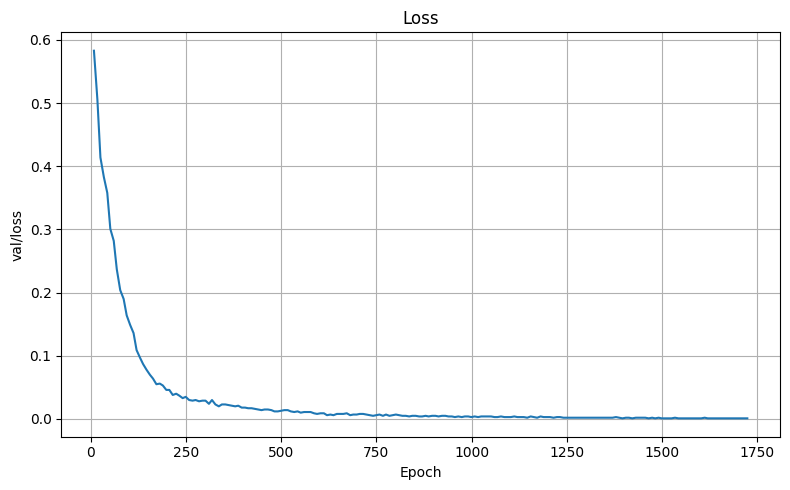

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/loss")
plt.title("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/loss.png")
plt.show()

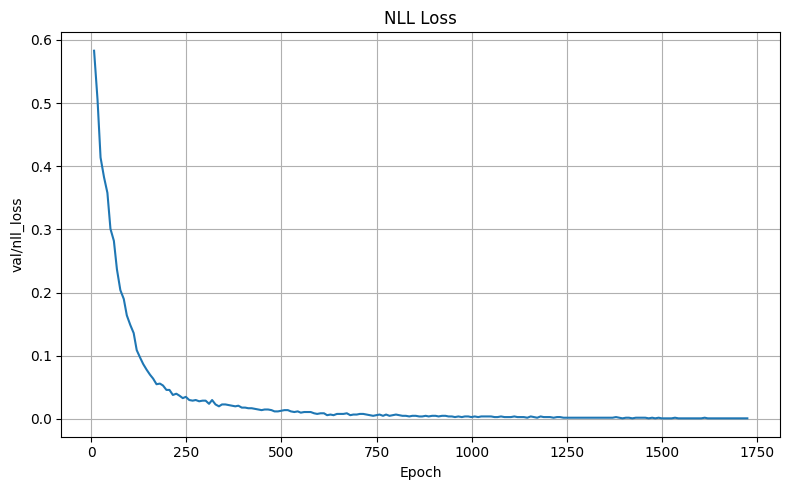

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, nll_loss, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/nll_loss")
plt.title("NLL Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/NLL_loss.png")
plt.show()

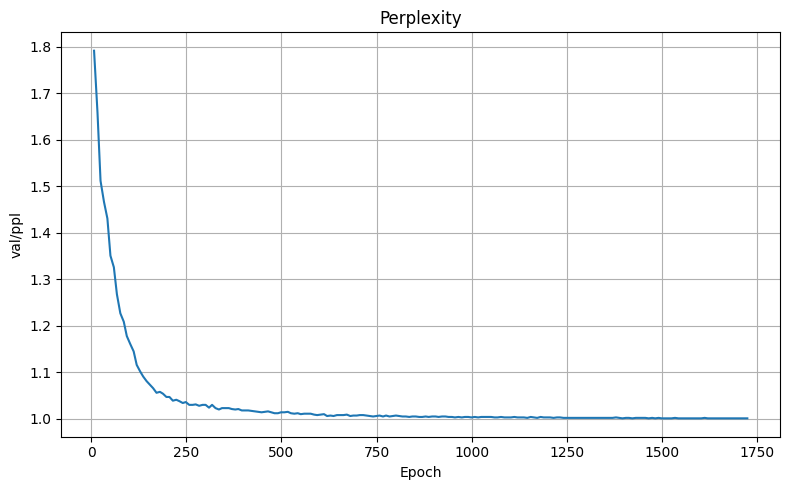

In [57]:
# ChatGPT Summary of ppl metric:
# ppl (Perplexity) — Model-Level Metric
# What it measures: How well the trained language model predicts or generates sequences.
#
# Scope: Evaluates the model's understanding of protein sequence patterns.
#
# When it's used: During training or evaluation of a protein language model (like DPLM).
#
# Lower is better: A lower perplexity indicates the model is more confident and accurate in predicting sequences.

plt.figure(figsize=(8, 5))
plt.plot(epochs, ppl, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/ppl")
plt.title("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity.png")
plt.show()

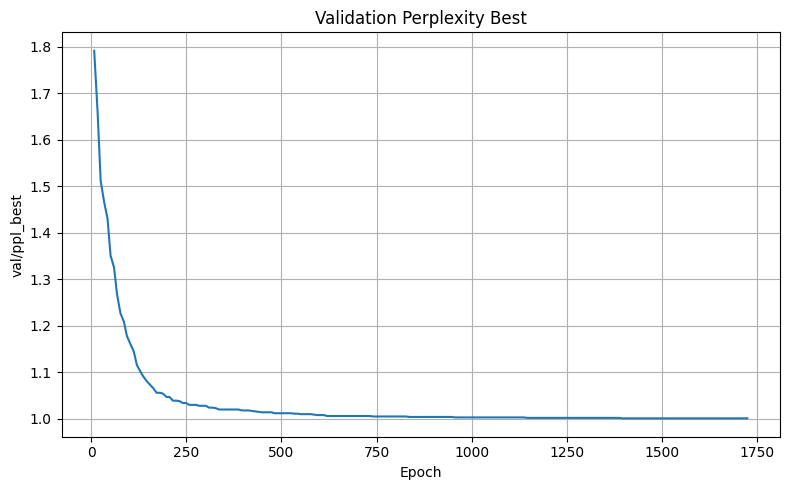

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, ppl_best, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/ppl_best")
plt.title("Validation Perplexity Best")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_best.png")
plt.show()

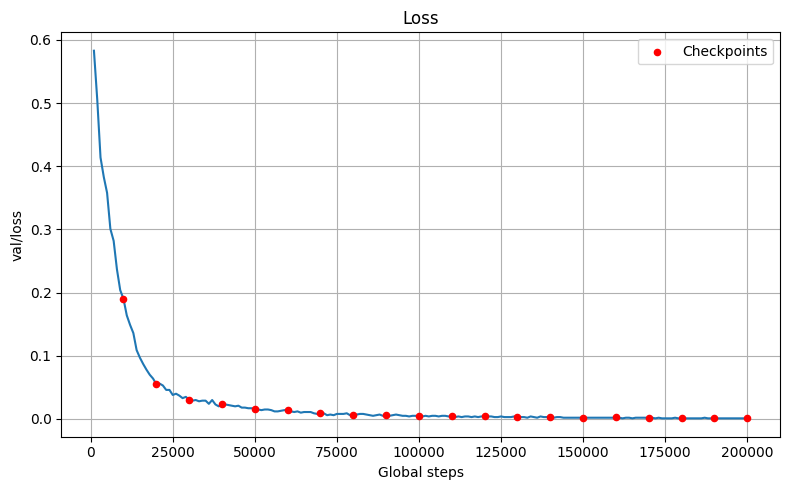

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, losses, marker="")
plt.scatter(checkpoints, [losses[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/loss")
plt.title("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/loss_global_steps.png")
plt.show()

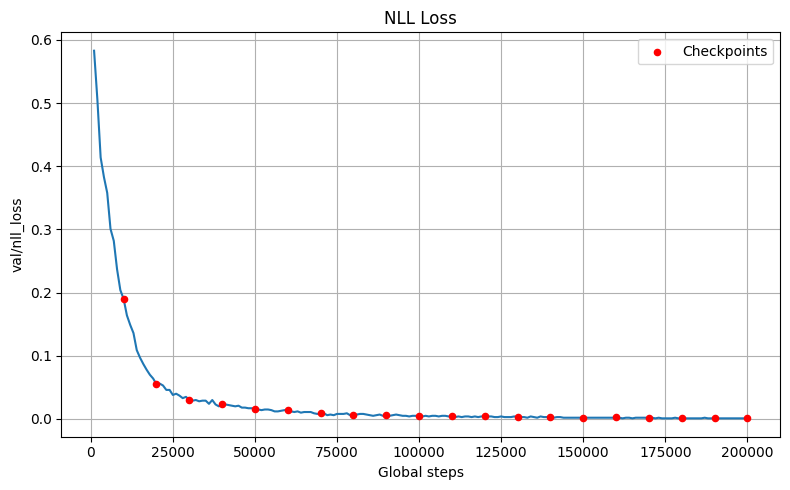

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, nll_loss, marker="")
plt.scatter(checkpoints, [nll_loss[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/nll_loss")
plt.title("NLL Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/NLL_loss_global_steps.png")
plt.show()

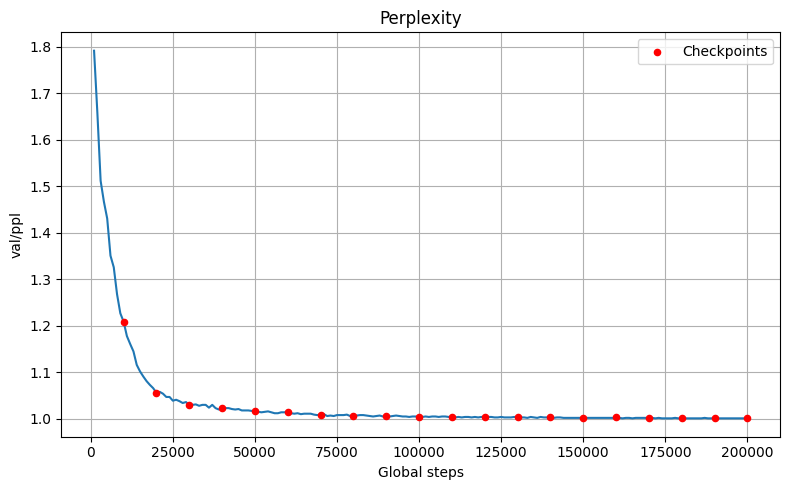

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, ppl, marker="")
plt.scatter(checkpoints, [ppl[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/ppl")
plt.title("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_global_steps.png")
plt.show()

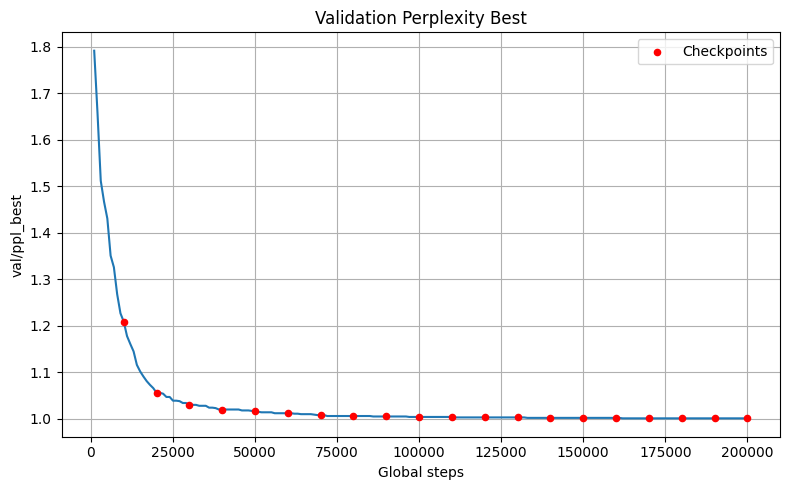

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, ppl_best, marker="")
plt.scatter(checkpoints, [ppl_best[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/ppl_best")
plt.title("Validation Perplexity Best")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_best_global_steps.png")
plt.show()